In [ ]:
# Load peristim matrix
from pathlib import Path
import numpy as np
import json
%matplotlib inline
import matplotlib.pyplot as plt

import RCP_analysis as rcp

# Paths
REPO_ROOT = Path().resolve().parents[2]
PARAMS = rcp.load_experiment_params(REPO_ROOT / "config" / "params.yaml", repo_root=REPO_ROOT)

SESSION_LOC = (Path(PARAMS.data_root) / Path(PARAMS.location)).resolve()
OUT_BASE = SESSION_LOC / "results"
OUT_BASE.mkdir(parents=True, exist_ok=True)

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"

CONTROL_PERI_ROOT = PERI_ROOT / "control_reaches"
AT_REST_PERI_ROOT  = PERI_ROOT / "at_rest"
STIM_PERI_ROOT  = PERI_ROOT / "stim_reaches"

FILE = 'peristim__NRR_RW_013_260129_135327__BR_003_target_A.npz'

target_dir = STIM_PERI_ROOT / 'target_A'
npz_path = target_dir / FILE
peristim_npz = np.load(npz_path, allow_pickle=True)
NPRW_rates_zeroed = peristim_npz['NPRW_rates_zeroed']

meta_str = peristim_npz['meta_json'].item()
meta = json.loads(meta_str)
stim_dur = meta["recording_stim_dur"]

In [2]:
NPRW_rel_t = peristim_npz['NPRW_rel_t']
NPRW_peak_ms_dedup = peristim_npz['NPRW_peak_ms_dedup']
NPRW_counts = peristim_npz['NPRW_counts']
NPRW_rates_zeroed = peristim_npz['NPRW_rates_zeroed']
# peristim_npz['stim_ms']

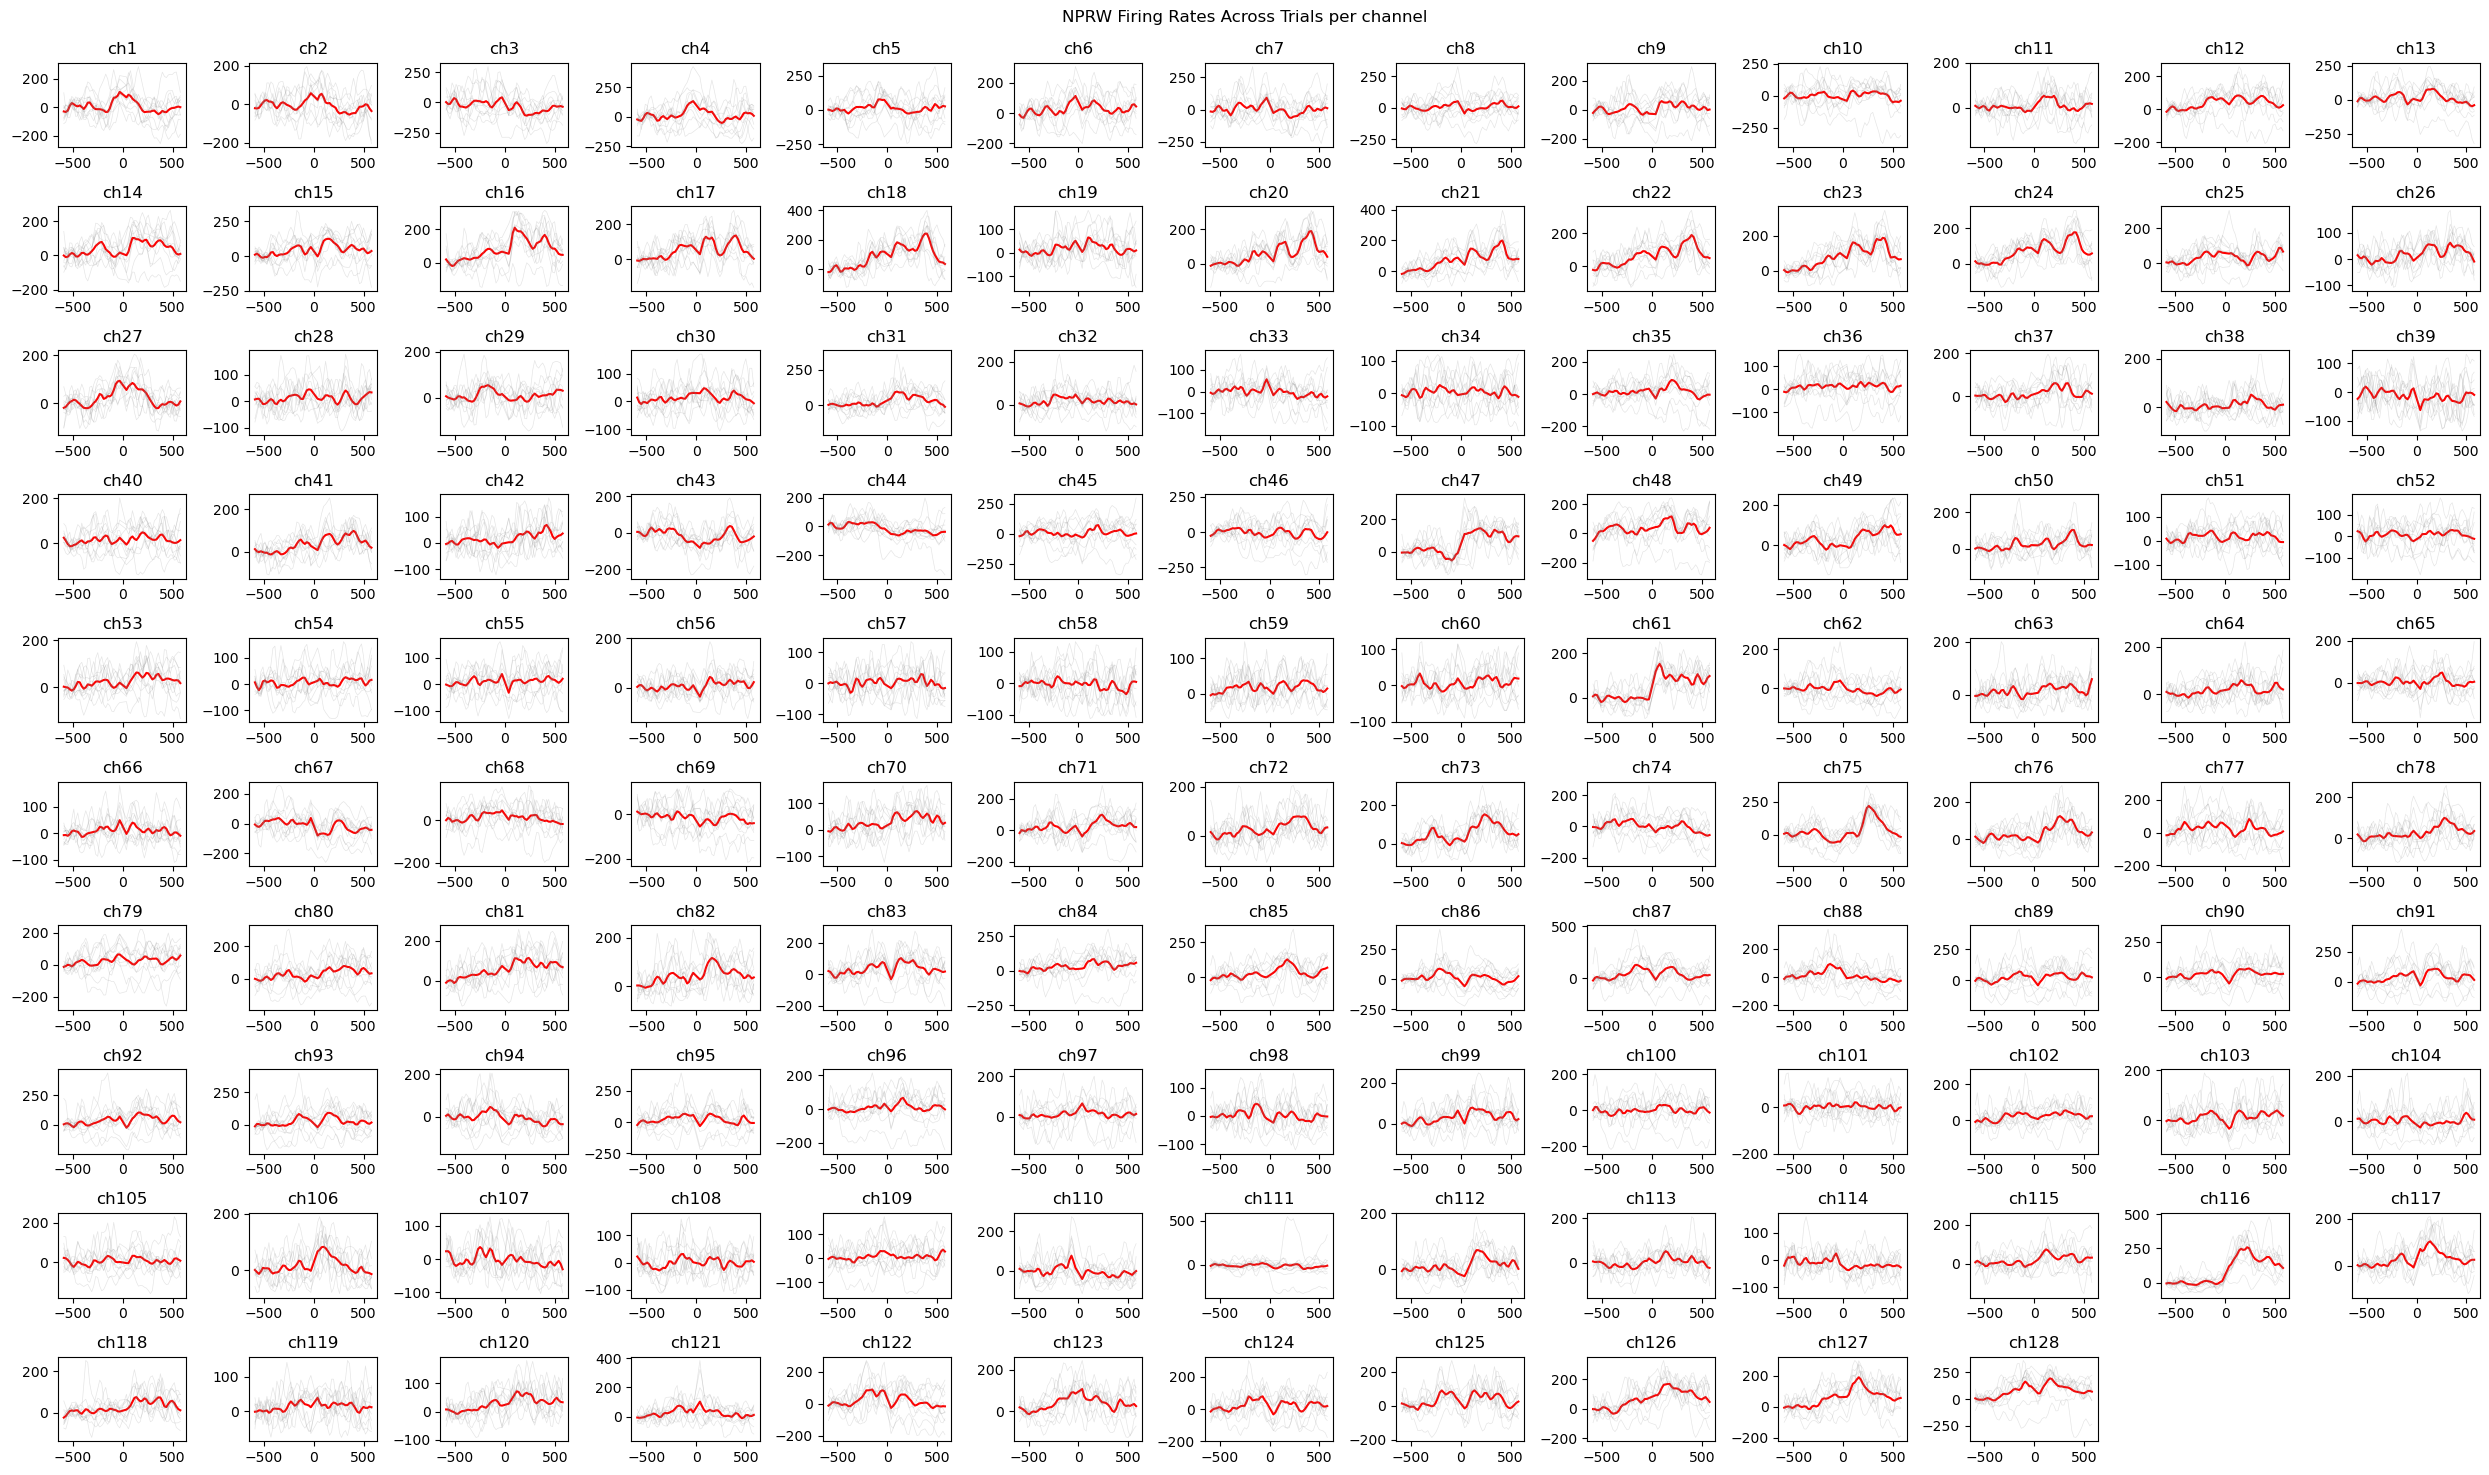

In [112]:
plt.figure(figsize=(25, 15))
for ch_select in range(128):
    plt.subplot(10,13, ch_select+1)
    plt.plot(NPRW_rel_t, np.nanmean(NPRW_rates_zeroed[:, ch_select, :], axis = 0).T,color="red")
    plt.plot(NPRW_rel_t, NPRW_rates_zeroed[:, ch_select, :].T,color="gray",linewidth=0.5,alpha=0.2)
    plt.title("ch" + str(ch_select + 1))
    
plt.suptitle("NPRW Firing Rates Across Trials per channel\n")
plt.tight_layout()

# NPRW_rates_zeroed.shape

In [113]:
NPRW_rel_t

array([-590. , -570. , -550. , -530. , -510. , -490. , -470. , -450. ,
       -430. , -410. , -390. , -370. , -350. , -330. , -310. , -290. ,
       -270. , -250. , -230. , -210. , -190. , -170. , -150. , -130. ,
       -110. ,  -90. ,  -70. ,  -50. ,  -30. ,   37.8,   57.8,   77.8,
         97.8,  117.8,  137.8,  157.8,  177.8,  197.8,  217.8,  237.8,
        257.8,  277.8,  297.8,  317.8,  337.8,  357.8,  377.8,  397.8,
        417.8,  437.8,  457.8,  477.8,  497.8,  517.8,  537.8,  557.8,
        577.8])

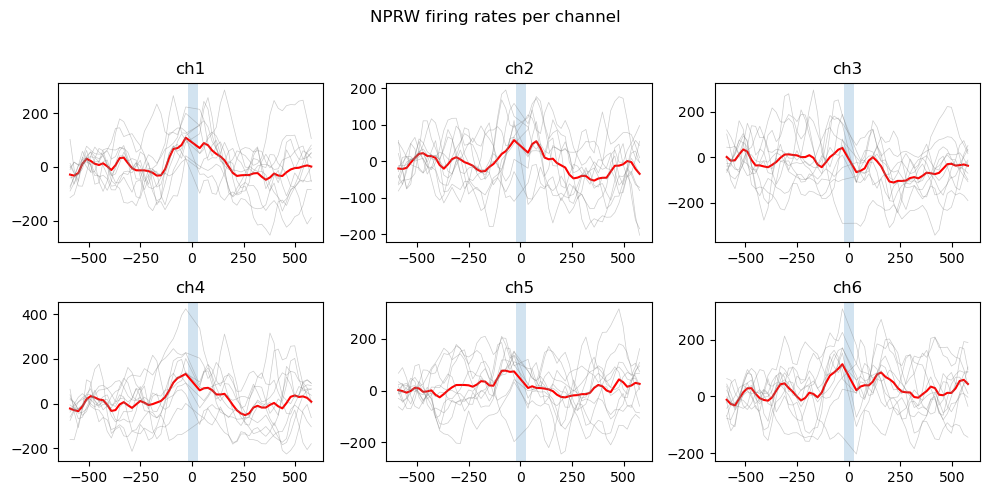

In [114]:
plt.figure(figsize=(10, 5))
for ch_select in range(6):
    ax = plt.subplot(2, 3, ch_select+1)
    plt.plot(NPRW_rel_t, np.nanmean(NPRW_rates_zeroed[:, ch_select, :], axis = 0).T,color="red")
    plt.plot(NPRW_rel_t, NPRW_rates_zeroed[:, ch_select, :].T,color="gray",linewidth=0.5,alpha=0.4)
    plt.title("ch" + str(ch_select + 1))
    ax.axvspan(-20, 20+stim_dur, alpha=0.2)
    
plt.suptitle("NPRW firing rates per channel\n")
plt.tight_layout()

In [115]:
NPRW_rates_zeroed.shape

(11, 128, 57)

In [116]:
import re
from sklearn.decomposition import PCA

# BR ranges
found_files = {}
files = []

for f in target_dir.glob("peristim__*.npz"):
    files.append(f)

found_files = sorted(files)

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

# --- load + keep provenance labels ---
NPRW_list = []
file_labels = []   # one label per trial (same length as axis 0 after concat)

for file_idx, f in enumerate(found_files[1:]): # Remove first file
    with np.load(f, allow_pickle=True) as npz:
        arr = npz["NPRW_rates_zeroed"]          # shape (n_trials_in_file, ...)
    NPRW_list.append(arr)
    file_labels.extend([file_idx] * arr.shape[0])

NPRW_rates_zeroed_tA = np.concatenate(NPRW_list, axis=0)
file_labels = np.asarray(file_labels, dtype=int)

print("tA shape:", NPRW_rates_zeroed_tA.shape)
print("#files:", len(NPRW_list), "label shape:", file_labels.shape)
print("trials per file:", np.bincount(file_labels))

tA shape: (579, 128, 57)
#files: 60 label shape: (579,)
trials per file: [11  6 11  4 10 10 10 10  7 10 11 10 13  9 10 11  8  9 11  8 10  8 10 10
  8 10 10 10  9 10  9  7 10 10  9 12 10 10 10 11 13 10  9 10 12 12  8  9
 11  9 11  8  8 17  7  8  8 10  7 10]


In [118]:
file_labels

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  5,  5,  5,  5,  5,  5,  5,  5,  5,
        5,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  7,  7,  7,  7,  7,  7,
        7,  7,  7,  7,  8,  8,  8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,
        9,  9,  9,  9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
       16, 16, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 17, 17, 17, 17,
       18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 19, 19, 19, 19, 19, 19,
       19, 19, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21,
       21, 21, 21, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 23, 23, 23, 23,
       23, 23, 23, 23, 23

In [119]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=0)
train_idx, test_idx = next(sss.split(np.zeros(len(file_labels)), file_labels))

X_train = NPRW_rates_zeroed_tA[train_idx]
X_test  = NPRW_rates_zeroed_tA[test_idx]

labels_train = file_labels[train_idx]
labels_test  = file_labels[test_idx]

print("train trials per file:", np.bincount(labels_train))
print("test trials per file: ", np.bincount(labels_test))


train trials per file: [ 8  4  8  3  7  7  7  7  5  7  8  7  9  6  7  8  5  6  8  6  7  5  7  7
  5  7  7  7  6  7  6  5  7  7  6  8  7  7  7  8  9  7  6  7  8  8  6  6
  8  6  8  6  6 12  5  6  6  7  5  7]
test trials per file:  [3 2 3 1 3 3 3 3 2 3 3 3 4 3 3 3 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 2 3 3 3 4 3
 3 3 3 4 3 3 3 4 4 2 3 3 3 3 2 2 5 2 2 2 3 2 3]


In [120]:
NPRW_rates_zeroed_tA.shape

(579, 128, 57)

In [121]:
X_train.shape

(405, 128, 57)

In [122]:
X_test.shape

(174, 128, 57)

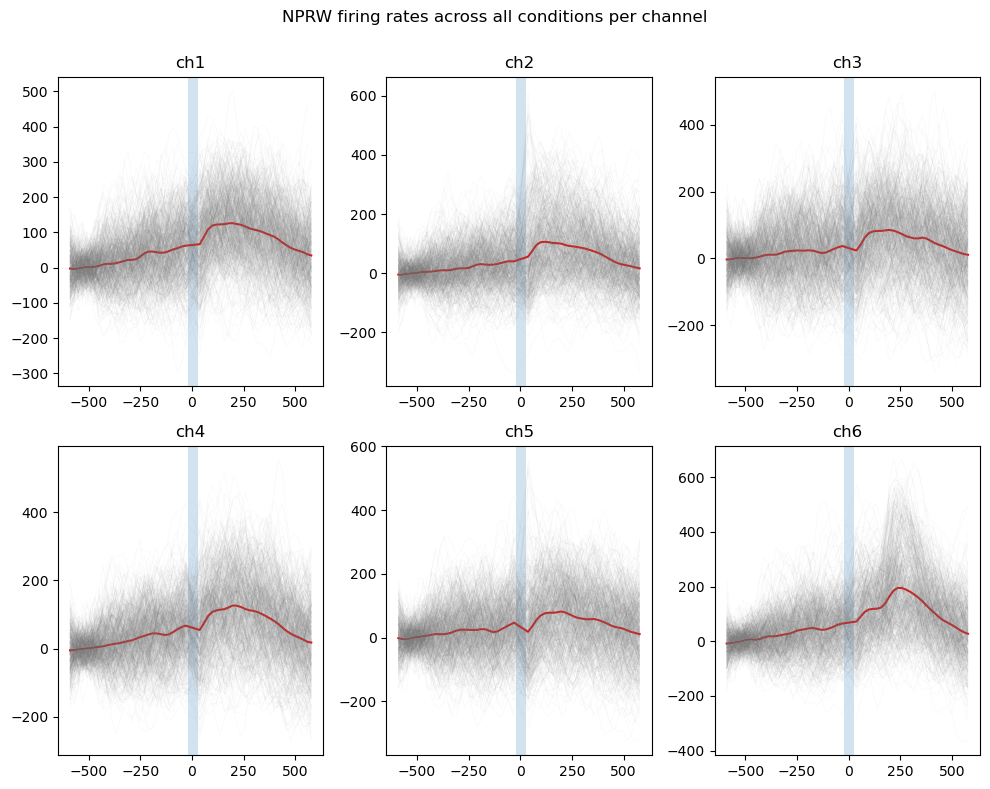

In [123]:
plt.figure(figsize=(10, 8))
for ch_select in range(6):
    ax = plt.subplot(2, 3, ch_select+1)
    plt.plot(NPRW_rel_t, np.nanmean(NPRW_rates_zeroed_tA[:, ch_select, :], axis = 0).T,color="red")
    plt.plot(NPRW_rel_t, NPRW_rates_zeroed_tA[:, ch_select, :].T,color="gray",linewidth=0.5,alpha=0.05)
    plt.title("ch" + str(ch_select + 1))
    ax.axvspan(-20, 20+stim_dur, alpha=0.2)
    
plt.suptitle("NPRW firing rates across all conditions per channel\n")
plt.tight_layout()

In [124]:
from sklearn.decomposition import PCA

X = np.transpose(NPRW_rates_zeroed_tA, axes=(0, 2, 1))  # (n_trials, n_bins, n_ch)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

num_PCs = 20
train_frac = 0.7

n_trials, n_bins, n_ch = X.shape
n_comp = min(num_PCs, n_bins, n_ch)

# Preallocate latents over time for each trial, and explained variance
pcs_all = np.zeros((n_trials, n_comp, n_bins), dtype=np.float32)
explained_var_all = np.zeros((n_trials, n_comp), dtype=np.float32)

mse_test = np.full(n_trials, np.nan, dtype=np.float32)

for trial in range(n_trials):
    # PCA for each trial
    X_trial = X[trial, :, :]  # (n_bins, n_ch)
    total_var_trial = np.var(X_trial, axis=0).sum() # Total variance over time, but summed over channels
    if n_comp >= 1 and total_var_trial > 0.0:
        pca = PCA(n_components=n_comp) # For consistency
        pcs_trial = pca.fit_transform(X_trial)  # (n_bins, n_comp)
        pcs_all[trial] = pcs_trial.T.astype(np.float32)
        explained_var_all[trial] = np.nan_to_num(
            pca.explained_variance_ratio_, nan=0.0)
    else:
        pcs_all[trial] = 0.0
        explained_var_all[trial] = 0.0

In [125]:
pcs_all.shape

(579, 20, 57)

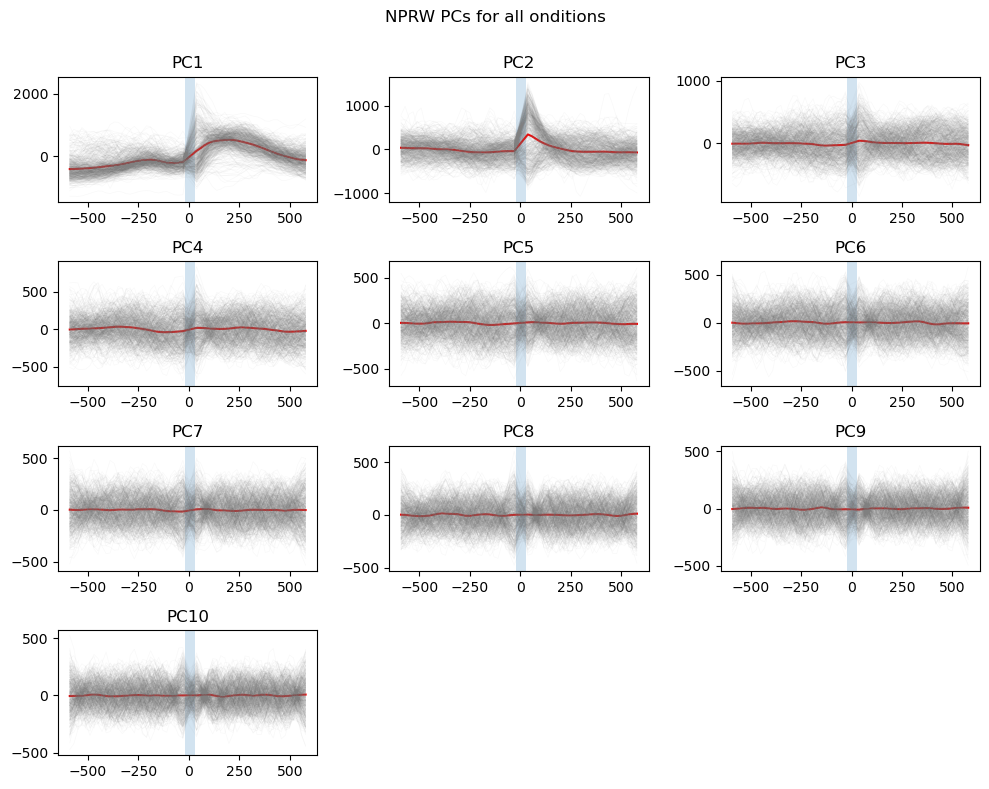

In [126]:
plt.figure(figsize=(10, 8))
for ch_select in range(10):
    ax = plt.subplot(4, 3, ch_select+1)
    plt.plot(NPRW_rel_t, np.nanmean(pcs_all[:, ch_select, :], axis = 0).T,color="red")
    plt.plot(NPRW_rel_t, pcs_all[:, ch_select, :].T,color="gray",linewidth=0.5,alpha=0.05)
    plt.title("PC" + str(ch_select + 1))
    ax.axvspan(-20, 20+stim_dur, alpha=0.2)
    
plt.suptitle("NPRW PCs for all onditions\n")
plt.tight_layout()

In [127]:
explained_var_all.shape

(579, 20)

In [128]:
num_PCs = 30
n_trials, n_bins, n_ch = X.shape
max_k = min(num_PCs, n_bins, n_ch)

X_train_flat = X[train_idx].reshape(-1, n_ch)
pca = PCA(n_components=max_k, random_state=0)
pca.fit(X_train_flat)

X_test_flat = X[test_idx].reshape(-1, n_ch)

Xc = X_test_flat - X_test_flat.mean(axis=0, keepdims=True) # Zero out test data
sst = np.sum(Xc ** 2) # normalization constant / total sum of squares

Z_full = pca.transform(X_test_flat)  # project test data onto PCs (bins times trials, n_components)
test_r2 = np.zeros(max_k, dtype=float)

for k in range(1, max_k + 1):
    X_hat = Z_full[:, :k] @ pca.components_[:k, :] + pca.mean_      # reconstruct test data using first k PCs
    sse = np.sum((X_test_flat - X_hat) ** 2)                        # sum of squared errors
    test_r2[k - 1] = 0.0 if sst == 0 else (1.0 - sse / sst)         # explained variance


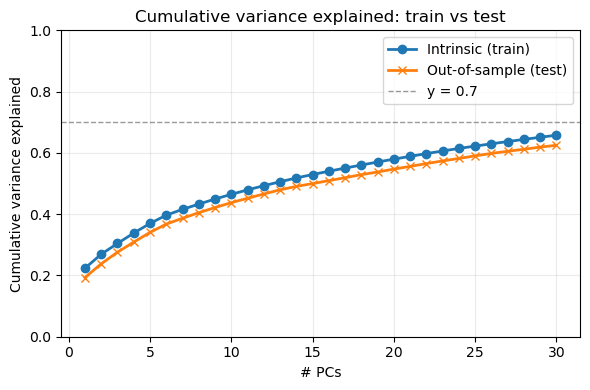

In [ ]:
k = np.arange(1, max_k + 1)

train_cum = np.cumsum(pca.explained_variance_ratio_[:max_k])
test_cum = test_r2

plt.figure(figsize=(6, 4))
plt.plot(k, train_cum, marker="o", linewidth=2, label="Train")
plt.plot(k, test_cum, marker="x", linewidth=2, label="Test")
plt.axhline(y=0.5, linestyle="--", color="gray", linewidth=1, alpha=0.8, label="y = 0.5")
plt.xlabel("# PCs")
plt.ylabel("Cumulative variance explained")
plt.title("Cumulative variance explained: train vs test")
plt.ylim(0, 1)
plt.grid(True, alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()
